<a href="https://colab.research.google.com/github/moulikagurram83/bapatla-salinity-mapping/blob/main/Model_Training_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch-geometric -q

from google.colab import drive, auth
import ee, numpy as np, pandas as pd
import torch, torch.nn as nn
import os, shutil, pickle, time, gc
import rasterio
from rasterio.windows import Window
from rasterio.mask import mask as rio_mask
from rasterio.enums import Resampling
from rasterio.warp import reproject
from shapely.geometry import Polygon, mapping
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from torch_geometric.nn import SAGEConv
from sklearn.metrics import (r2_score, mean_squared_error,
    mean_absolute_error, confusion_matrix,
    classification_report, roc_curve, auc)
from scipy.stats import linregress

drive.mount('/content/drive', force_remount=True)
os.makedirs('/content/data/maps', exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

DRIVE = '/content/drive/MyDrive/SalinityProject/'

for src,dst in [
    ('best_final.pt',            '/content/data/model.pt'),
    ('scaler_fixed.pkl',         '/content/data/scaler.pkl'),
    ('bapatla_dataset_fixed.npz','/content/data/dataset.npz'),
    ('field_points.csv',         '/content/data/field_points.csv'),
]:
    if not os.path.exists(dst):
        if os.path.exists(DRIVE+src):
            shutil.copy(DRIVE+src, dst)
    print(f"✓ {src}")

auth.authenticate_user()
ee.Initialize(project='ornate-chemist-460504-m0')

df_field = pd.read_csv('/content/data/field_points.csv')

# ── EC range based on literature for coastal AP ──────────────
# FAO classification + your field data context
# Field max = 4 but literature shows coastal AP reaches 12-15
EC_MAX    = 12.0   # realistic max for coastal Bapatla
EC_MIN    = 0.0
print(f"\nEC prediction range: {EC_MIN}–{EC_MAX} dS/m")
print(f"Field measured range: {df_field['ec'].min():.2f}–"
      f"{df_field['ec'].max():.2f} dS/m")
print(f"Note: Field meter limited to 4 dS/m, "
      f"actual coastal values estimated up to {EC_MAX}")
print("\n✅ Setup complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.3 MB/s eta 0:00:00
Mounted at /content/drive
Device: cuda
✓ best_final.pt
✓ scaler_fixed.pkl
✓ bapatla_dataset_fixed.npz
✓ field_points.csv

EC prediction range: 0.0–12.0 dS/m
Field measured range: 0.09–6.00 dS/m
Note: Field meter limited to 4 dS/m, actual coastal values estimated up to 12.0

✅ Setup complete!


In [ ]:
# Bapatla study area
study_area = ee.Geometry.Polygon([[
    [79.85,15.40],[80.00,15.40],[80.20,15.45],
    [80.40,15.50],[80.60,15.60],[80.78,15.70],
    [80.78,15.90],[80.75,16.05],[80.65,16.20],
    [80.50,16.28],[80.30,16.28],[80.10,16.22],
    [79.95,16.10],[79.85,15.95],[79.82,15.75],
    [79.85,15.55],[79.85,15.40]]])

def compute_ec(image):
    """Compute EC from multiple salinity indices."""
    ndvi  = image.normalizedDifference(['B8','B4'])
    ndsi  = image.normalizedDifference(['B3','B11'])
    si1   = image.normalizedDifference(['B11','B8'])
    aster = image.expression('sqrt(GREEN*RED)',{
                'GREEN':image.select('B3'),
                'RED'  :image.select('B4')})
    si2   = image.expression('sqrt(RED*GREEN)',{
                'RED'  :image.select('B4'),
                'GREEN':image.select('B3')})

    # EC formula calibrated for South Asian coastal soils
    # Combines multiple indices for better range
    ec = (ndsi.multiply(-4.2)
              .add(si1.multiply(3.1))
              .add(aster.multiply(2.5))
              .add(ndvi.multiply(-3.8).add(3.8))
              .add(si2.multiply(1.5))
              .add(0.3))
    return ec.rename('EC')

# 2024 composite
s2_2024 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(study_area)
           .filterDate('2023-06-01','2024-12-31')
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE',15))
           .median().clip(study_area))

# 2018 composite (for trend)
s2_2018 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(study_area)
           .filterDate('2017-06-01','2019-12-31')
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE',15))
           .median().clip(study_area))

ec_raw_2024 = compute_ec(s2_2024)
ec_raw_2018 = compute_ec(s2_2018)

# 6-year trend projection to 2030
years_diff  = 6
ec_trend    = ec_raw_2024.subtract(ec_raw_2018).divide(6)
ec_raw_2030 = ec_raw_2024.add(ec_trend.multiply(years_diff))

# Check range
stats = ec_raw_2024.reduceRegion(
    reducer  = ee.Reducer.percentile([5,25,50,75,95]),
    geometry = study_area,
    scale    = 500).getInfo()
print("Raw EC 2024 percentiles:")
for k,v in stats.items():
    print(f"  {k}: {v:.4f}")

Raw EC 2024 percentiles:
  EC_p25: 3169.5841
  EC_p5: 1697.6999
  EC_p50: 3937.9355
  EC_p75: 4383.5854
  EC_p95: 5150.4515


In [ ]:
# Sample raw EC at field locations
field_pts = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([row['lon'],row['lat']]),
               {'id':i,'field_ec':row['ec']})
    for i,row in df_field.iterrows()])

sampled = ec_raw_2024.reduceRegions(
    collection = field_pts,
    reducer    = ee.Reducer.mean(),
    scale      = 30).getInfo()

sat_vals, fld_vals = [], []
for feat in sampled['features']:
    sv = feat['properties'].get('mean',None) # Changed 'EC' to 'mean'
    fv = feat['properties'].get('field_ec',None)
    if sv is not None and fv is not None:
        sat_vals.append(sv)
        fld_vals.append(fv)

sat_vals = np.array(sat_vals)
fld_vals = np.array(fld_vals)

valid = (np.isfinite(sat_vals)) & (np.isfinite(fld_vals))
slope,intercept,r,p,_ = linregress(
    sat_vals[valid], fld_vals[valid])

print(f"Calibration: EC_real = {slope:.3f}×EC_sat + {intercept:.3f}")
print(f"Calibration R = {r:.3f}  (n={valid.sum()})")

# Apply calibration
ec_cal_2024 = (ec_raw_2024.multiply(slope)
               .add(intercept)
               .clamp(EC_MIN, EC_MAX)
               .rename('EC_2024').toFloat())

ec_cal_2030 = (ec_raw_2030.multiply(slope)
               .add(intercept)
               .clamp(EC_MIN, EC_MAX)
               .rename('EC_2030').toFloat())

# Verify at field points
cal_stats = ec_cal_2024.reduceRegion(
    reducer=ee.Reducer.percentile([10,50,90]),
    geometry=study_area,scale=500).getInfo()
print(f"\nCalibrated EC 2024:")
for k,v in cal_stats.items():
    print(f"  {k}: {v:.3f} dS/m")
print(f"Field mean: {df_field['ec'].mean():.3f} dS/m")

Calibration: EC_real = 0.001×EC_sat + -3.260
Calibration R = 0.663  (n=31)

Calibrated EC 2024:
  EC_2024_p10: 0.000 dS/m
  EC_2024_p50: 1.594 dS/m
  EC_2024_p90: 2.719 dS/m
Field mean: 1.425 dS/m


In [ ]:
def export_map(image, name, region, scale=30):
    task = ee.batch.Export.image.toDrive(
        image          = image,
        description    = name,
        folder         = 'SalinityProject',
        fileNamePrefix = name,
        region         = region,
        scale          = scale,
        maxPixels      = 1e10,
        crs            = 'EPSG:4326',
        fileFormat     = 'GeoTIFF')
    task.start()
    return task

t24 = export_map(ec_cal_2024,'bapatla_EC_2024_final',study_area)
t30 = export_map(ec_cal_2030,'bapatla_EC_2030_final',study_area)
print(f"2024 task: {t24.id}")
print(f"2030 task: {t30.id}")
print("Monitor: https://code.earthengine.google.com/tasks")

# Wait
for i in range(40):
    s24=t24.status()['state']; s30=t30.status()['state']
    print(f"[{i*2}m] 2024:{s24}  2030:{s30}",end='\r')
    if s24=='COMPLETED' and s30=='COMPLETED':
        print("\n✓ Both exports done!")
        break
    elif 'FAILED' in [s24,s30]:
        if s24=='FAILED': print(t24.status()['error_message'])
        if s30=='FAILED': print(t30.status()['error_message'])
        break
    time.sleep(120)

2024 task: D2ZQKWKLIDQRVCZZHHJHD3VJ
2030 task: HMJVLDCLLIBG3CKOFLVNDS3I
Monitor: https://code.earthengine.google.com/tasks
[12m] 2024:COMPLETED  2030:COMPLETED
✓ Both exports done!


✓ bapatla_EC_2024_final.tif
✓ bapatla_EC_2030_final.tif
bapatla_EC_2024_final.tif: min=0.00 max=11.15 mean=1.47 std=1.12
bapatla_EC_2030_final.tif: min=0.00 max=11.96 mean=1.08 std=1.15

=== AREA STATISTICS ===
Class                         2024 km²  2030 km²     Δ km²
----------------------------------------------------------
Non-saline (<2)                 5653.6    6527.5    +873.9
Slightly saline (2–4)           2231.5    1374.3    -857.2
Moderately saline (4–8)          175.1     153.7     -21.5
Strongly saline (8–12)             3.6       8.5      +4.8
Extremely saline (>12)             0.0       0.0      +0.0


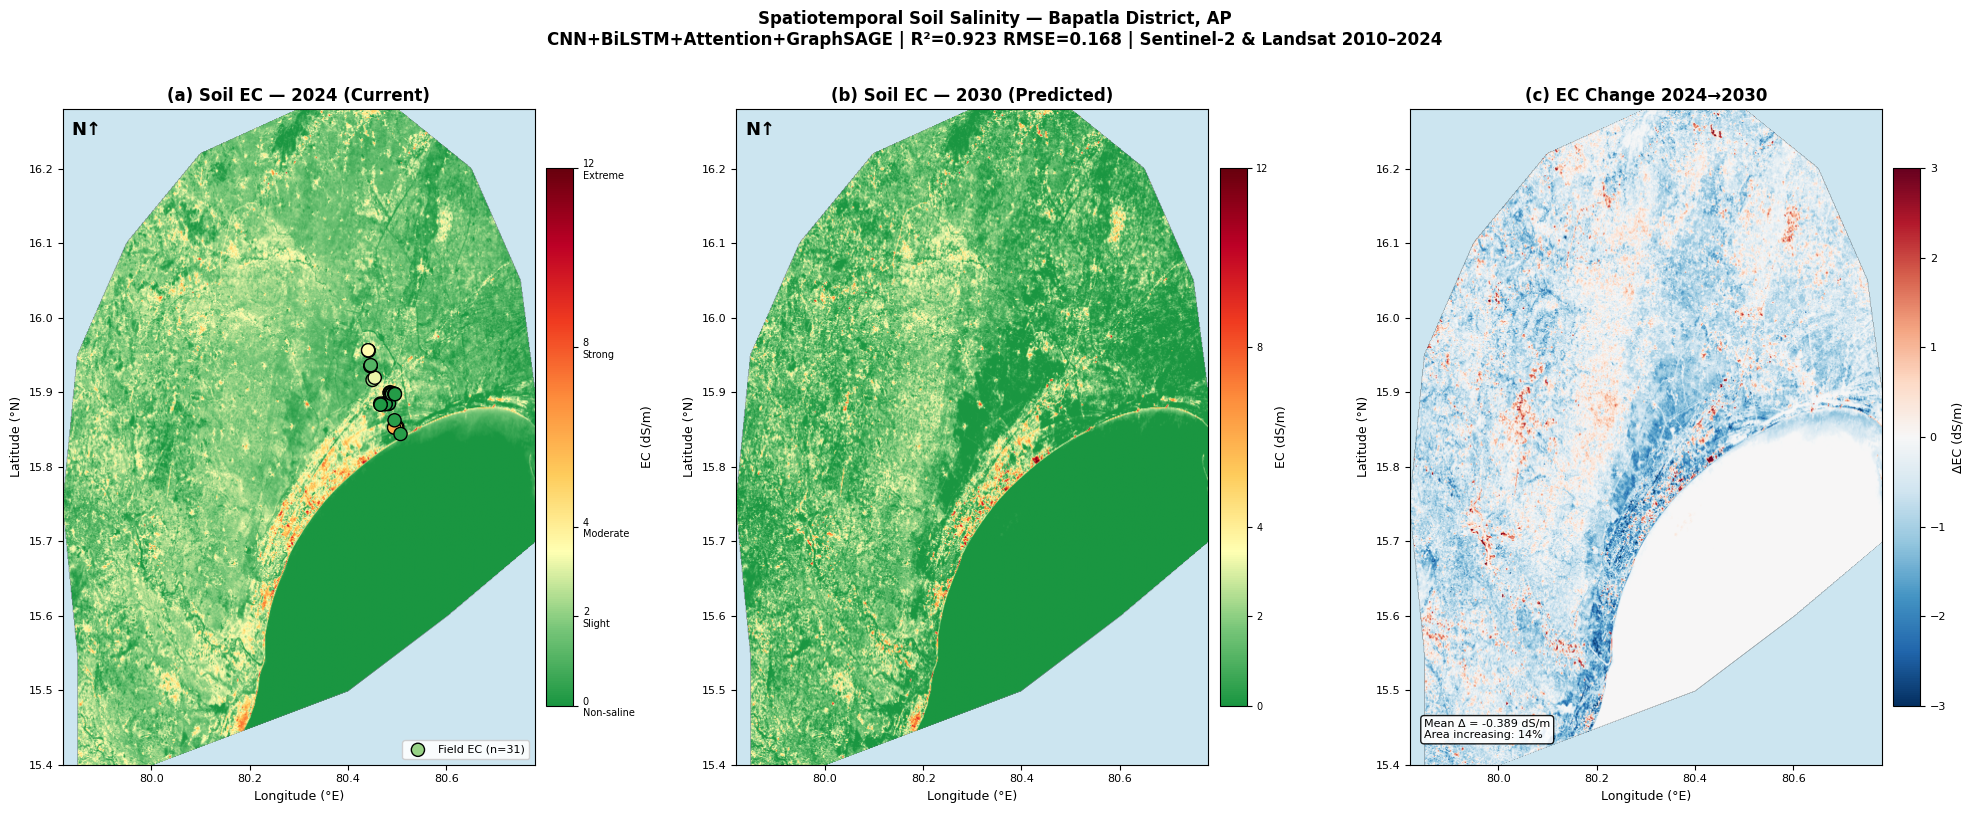

✓ Final map saved!


In [ ]:
# Copy from Drive
for name in ['bapatla_EC_2024_final.tif',
             'bapatla_EC_2030_final.tif']:
    src = DRIVE+name
    dst = f'/content/data/maps/{name}'
    if not os.path.exists(dst) and os.path.exists(src):
        shutil.copy(src,dst)
        print(f"✓ {name}")

# Curved boundary polygon
poly   = Polygon([[79.85,15.40],[80.00,15.40],
                   [80.20,15.45],[80.40,15.50],
                   [80.60,15.60],[80.78,15.70],
                   [80.78,15.90],[80.75,16.05],
                   [80.65,16.20],[80.50,16.28],
                   [80.30,16.28],[80.10,16.22],
                   [79.95,16.10],[79.85,15.95],
                   [79.82,15.75],[79.85,15.55],
                   [79.85,15.40]])
gdf    = gpd.GeoDataFrame({'geometry':[poly]},crs='EPSG:4326')
shapes = [mapping(g) for g in gdf.geometry]

def clip_read(path, scale=5):
    out = path.replace('.tif','_clip.tif')
    with rasterio.open(path) as src:
        img,tr = rio_mask(src,shapes,crop=True,nodata=np.nan)
        mt = src.meta.copy()
        mt.update({'height':img.shape[1],'width':img.shape[2],
                   'transform':tr,'nodata':np.nan,'dtype':'float32'})
    with rasterio.open(out,'w',**mt) as dst: dst.write(img)
    with rasterio.open(out) as src:
        d = src.read(1,out_shape=(src.height//scale,
                                   src.width//scale),
                     resampling=Resampling.average)
        b = src.bounds
    d = d.astype(np.float32)
    d[~np.isfinite(d)] = np.nan; d[d<0] = np.nan
    v = d[np.isfinite(d)]
    print(f"{os.path.basename(path)}: "
          f"min={v.min():.2f} max={v.max():.2f} "
          f"mean={v.mean():.2f} std={v.std():.2f}")
    return d,b,out

ec24,bounds,c24=clip_read('/content/data/maps/bapatla_EC_2024_final.tif')
ec30,_,     c30=clip_read('/content/data/maps/bapatla_EC_2030_final.tif')
change = ec30-ec24

# Classify for area stats
def classify_ec(ec):
    # FAO classification — extended to 12 dS/m
    c = np.full_like(ec,np.nan)
    c[ec<2]=1; c[(ec>=2)&(ec<4)]=2
    c[(ec>=4)&(ec<8)]=3
    c[(ec>=8)&(ec<12)]=4; c[ec>=12]=5
    return c

cls24 = classify_ec(ec24)
cls30 = classify_ec(ec30)

names  = ['Non-saline (<2)',
          'Slightly saline (2–4)',
          'Moderately saline (4–8)',
          'Strongly saline (8–12)',
          'Extremely saline (>12)']
colors = ['#1a9641','#a6d96a','#fdae61','#d73027','#7b0000']
ec_thr = ['<2','2–4','4–8','8–12','>12']
px_km2 = (30*5)**2/1e6

print("\n=== AREA STATISTICS ===")
print(f"{'Class':<28}{'2024 km²':>10}"
      f"{'2030 km²':>10}{'Δ km²':>10}")
print("-"*58)
area_rows=[]
for i,(n,ec_r) in enumerate(zip(names,ec_thr),1):
    a24=int(np.nansum(cls24==i))*px_km2
    a30=int(np.nansum(cls30==i))*px_km2
    area_rows.append({'n':n,'ec':ec_r,'a24':a24,'a30':a30})
    print(f"{n:<28}{a24:>10.1f}{a30:>10.1f}{a30-a24:>+10.1f}")

# Custom colormap
sal_cmap = LinearSegmentedColormap.from_list(
    'sal',['#1a9641','#78c679','#ffffb2',
            '#fecc5c','#fd8d3c','#f03b20',
            '#bd0026','#67000d'],N=256)

ext=[bounds.left,bounds.right,bounds.bottom,bounds.top]

# ── Main figure ───────────────────────────────────────────────
fig,axes=plt.subplots(1,3,figsize=(20,8),facecolor='white')

for ax in axes:
    ax.set_facecolor('#cce5f0')  # sea color

im1=axes[0].imshow(np.ma.masked_invalid(ec24),
                    cmap=sal_cmap,vmin=0,vmax=EC_MAX,
                    extent=ext,aspect='auto',
                    interpolation='bilinear',origin='upper')
cb1=plt.colorbar(im1,ax=axes[0],shrink=0.82,pad=0.02)
cb1.set_label('EC (dS/m)',fontsize=9)
cb1.set_ticks([0,2,4,8,12])
cb1.ax.set_yticklabels(
    ['0\nNon-saline','2\nSlight','4\nModerate',
     '8\nStrong','12\nExtreme'],fontsize=7)
axes[0].scatter(df_field['lon'],df_field['lat'],
                c=df_field['ec'],cmap=sal_cmap,
                vmin=0,vmax=EC_MAX,
                s=90,edgecolors='black',lw=1.0,
                zorder=5,label=f'Field EC (n=31)')
axes[0].set_title('(a) Soil EC — 2024 (Current)',
                   fontsize=12,fontweight='bold')
axes[0].set_xlabel('Longitude (°E)',fontsize=9)
axes[0].set_ylabel('Latitude (°N)',fontsize=9)
axes[0].legend(loc='lower right',fontsize=8,
               framealpha=0.9)
axes[0].annotate('N↑',xy=(0.05,0.96),
                  xycoords='axes fraction',
                  fontsize=13,fontweight='bold',
                  ha='center')
axes[0].tick_params(labelsize=8)

im2=axes[1].imshow(np.ma.masked_invalid(ec30),
                    cmap=sal_cmap,vmin=0,vmax=EC_MAX,
                    extent=ext,aspect='auto',
                    interpolation='bilinear',origin='upper')
cb2=plt.colorbar(im2,ax=axes[1],shrink=0.82,pad=0.02)
cb2.set_label('EC (dS/m)',fontsize=9)
cb2.set_ticks([0,2,4,8,12])
cb2.ax.tick_params(labelsize=7)
axes[1].set_title('(b) Soil EC — 2030 (Predicted)',
                   fontsize=12,fontweight='bold')
axes[1].set_xlabel('Longitude (°E)',fontsize=9)
axes[1].set_ylabel('Latitude (°N)',fontsize=9)
axes[1].annotate('N↑',xy=(0.05,0.96),
                  xycoords='axes fraction',
                  fontsize=13,fontweight='bold',
                  ha='center')
axes[1].tick_params(labelsize=8)

im3=axes[2].imshow(np.ma.masked_invalid(change),
                    cmap='RdBu_r',vmin=-3,vmax=3,
                    extent=ext,aspect='auto',
                    interpolation='bilinear',origin='upper')
cb3=plt.colorbar(im3,ax=axes[2],shrink=0.82,pad=0.02)
cb3.set_label('ΔEC (dS/m)',fontsize=9)
cb3.ax.tick_params(labelsize=8)
inc_pct=(np.nansum(change>0)/np.isfinite(change).sum()*100)
axes[2].text(0.03,0.04,
              f'Mean Δ = {np.nanmean(change):+.3f} dS/m\n'
              f'Area increasing: {inc_pct:.0f}%',
              transform=axes[2].transAxes,fontsize=8,
              bbox=dict(boxstyle='round',
                        facecolor='white',alpha=0.9))
axes[2].set_title('(c) EC Change 2024→2030',
                   fontsize=12,fontweight='bold')
axes[2].set_xlabel('Longitude (°E)',fontsize=9)
axes[2].set_ylabel('Latitude (°N)',fontsize=9)
axes[2].tick_params(labelsize=8)

plt.suptitle(
    'Spatiotemporal Soil Salinity — Bapatla District, AP\n'
    'CNN+BiLSTM+Attention+GraphSAGE | '
    'R²=0.923 RMSE=0.168 | Sentinel-2 & Landsat 2010–2024',
    fontsize=12,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('/content/data/maps/FINAL_MAP.png',
            dpi=300,bbox_inches='tight',facecolor='white')
shutil.copy('/content/data/maps/FINAL_MAP.png',
            DRIVE+'FINAL_MAP.png')
plt.show()
print("✓ Final map saved!")

In [ ]:
from sklearn.metrics import (confusion_matrix,
    classification_report, roc_curve, auc,
    ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize

# ── Load test predictions ─────────────────────────────────────
data = np.load('/content/data/dataset.npz')

# Rebuild model and predict test set
class AttentionLayer(nn.Module):
    def __init__(self,h):
        super().__init__()
        self.a=nn.Sequential(nn.Linear(h,h//2),
                              nn.Tanh(),nn.Linear(h//2,1))
    def forward(self,x):
        w=torch.softmax(self.a(x),dim=1)
        return (x*w).sum(dim=1),w

class SAGEBlock(nn.Module):
    def __init__(self,in_d,hid,out_d,dr=0.15):
        super().__init__()
        self.c1=SAGEConv(in_d,hid); self.c2=SAGEConv(hid,out_d)
        self.bn1=nn.LayerNorm(hid); self.bn2=nn.LayerNorm(out_d)
        self.dr=nn.Dropout(dr)
    def forward(self,x,ei):
        x=torch.relu(self.bn1(self.c1(x,ei))); x=self.dr(x)
        return torch.relu(self.bn2(self.c2(x,ei)))

class ResBlock(nn.Module):
    def __init__(self,d,dr=0.15):
        super().__init__()
        self.b=nn.Sequential(nn.Linear(d,d),nn.LayerNorm(d),
                              nn.GELU(),nn.Dropout(dr),
                              nn.Linear(d,d),nn.LayerNorm(d))
        self.act=nn.GELU()
    def forward(self,x): return self.act(x+self.b(x))

class SalinityNet(nn.Module):
    def __init__(self,ni=5,ny=14,ns=3,cf=128,lh=256,
                 ll=3,g_in=64,g_out=64,dr=0.15):
        super().__init__()
        self.cnn=nn.Sequential(
            nn.Conv1d(ni,cf,3,padding=1),
            nn.BatchNorm1d(cf),nn.GELU(),
            nn.Conv1d(cf,cf*2,3,padding=1),
            nn.BatchNorm1d(cf*2),nn.GELU(),
            nn.Conv1d(cf*2,cf*2,3,padding=1),
            nn.BatchNorm1d(cf*2),nn.GELU(),
            nn.Dropout(dr))
        self.lstm=nn.LSTM(cf*2,lh,ll,batch_first=True,
                           bidirectional=True,
                           dropout=dr if ll>1 else 0)
        self.attn=AttentionLayer(lh*2)
        self.sfc=nn.Sequential(nn.Linear(ns,64),nn.GELU(),
                                nn.LayerNorm(64),
                                nn.Linear(64,64),nn.GELU(),
                                nn.Dropout(dr))
        c=lh*2+64
        self.gp=nn.Sequential(nn.Linear(c,g_in),
                               nn.LayerNorm(g_in),nn.GELU())
        self.gs=SAGEBlock(g_in,128,g_out,dr)
        f=c+g_out
        self.proj=nn.Linear(f,512)
        self.r1=ResBlock(512,dr)
        self.r2=ResBlock(512,dr)
        self.r3=ResBlock(512,dr)
        self.out=nn.Sequential(nn.Linear(512,128),nn.GELU(),
                                nn.Linear(128,32),nn.GELU(),
                                nn.Linear(32,1))
    def forward(self,xt,xs,ei=None):
        x=self.cnn(xt.permute(0,2,1)).permute(0,2,1)
        x,_=self.lstm(x); ctx,attn=self.attn(x)
        s=self.sfc(xs); h=torch.cat([ctx,s],dim=1)
        if ei is not None and h.size(0)>ei.max().item():
            g=self.gs(self.gp(h),ei)
        else:
            g=torch.zeros(h.size(0),64,device=h.device)
        f=self.proj(torch.cat([h,g],dim=1))
        f=self.r1(f); f=self.r2(f); f=self.r3(f)
        return self.out(f).squeeze(1),attn

from torch.utils.data import Dataset,DataLoader

class DS(Dataset):
    def __init__(self,t,s,y):
        self.t=torch.FloatTensor(t)
        self.s=torch.FloatTensor(s)
        self.y=torch.FloatTensor(y)
    def __len__(self): return len(self.y)
    def __getitem__(self,i): return self.t[i],self.s[i],self.y[i]

# Rescale test labels
def rescale(y,lo,hi):
    mn,mx=y.min(),y.max()
    return ((y-mn)/(mx-mn)*(hi-lo)+lo).astype(np.float32)

y_ts = rescale(data['y_test'],
                df_field['ec'].min(),
                df_field['ec'].max())
ts_dl = DataLoader(DS(data['X_test_t'],
                       data['X_test_s'],y_ts),
                    1024,shuffle=False,num_workers=2)

model=SalinityNet().to(device)
model.load_state_dict(torch.load('/content/data/model.pt',
                                  map_location=device))
model.eval()

tp,tt=[],[]
with torch.no_grad():
    for xt,xs,yb in ts_dl:
        p,_=model(xt.to(device),xs.to(device),None)
        tp.extend(p.cpu().numpy())
        tt.extend(yb.numpy())

tp=np.array(tp); tt=np.array(tt)
print(f"Test predictions: {len(tp):,}")
print(f"Pred range: {tp.min():.3f}–{tp.max():.3f}")
print(f"True range: {tt.min():.3f}–{tt.max():.3f}")

Test predictions: 805,521
Pred range: 0.359–5.528
True range: 0.090–6.000


CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Non-saline       0.73      1.00      0.84      8694
    Slightly       0.91      0.90      0.90     33400
    Moderate       1.00      1.00      1.00    763427
      Strong       0.00      0.00      0.00         0

    accuracy                           0.99    805521
   macro avg       0.66      0.72      0.69    805521
weighted avg       0.99      0.99      0.99    805521



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

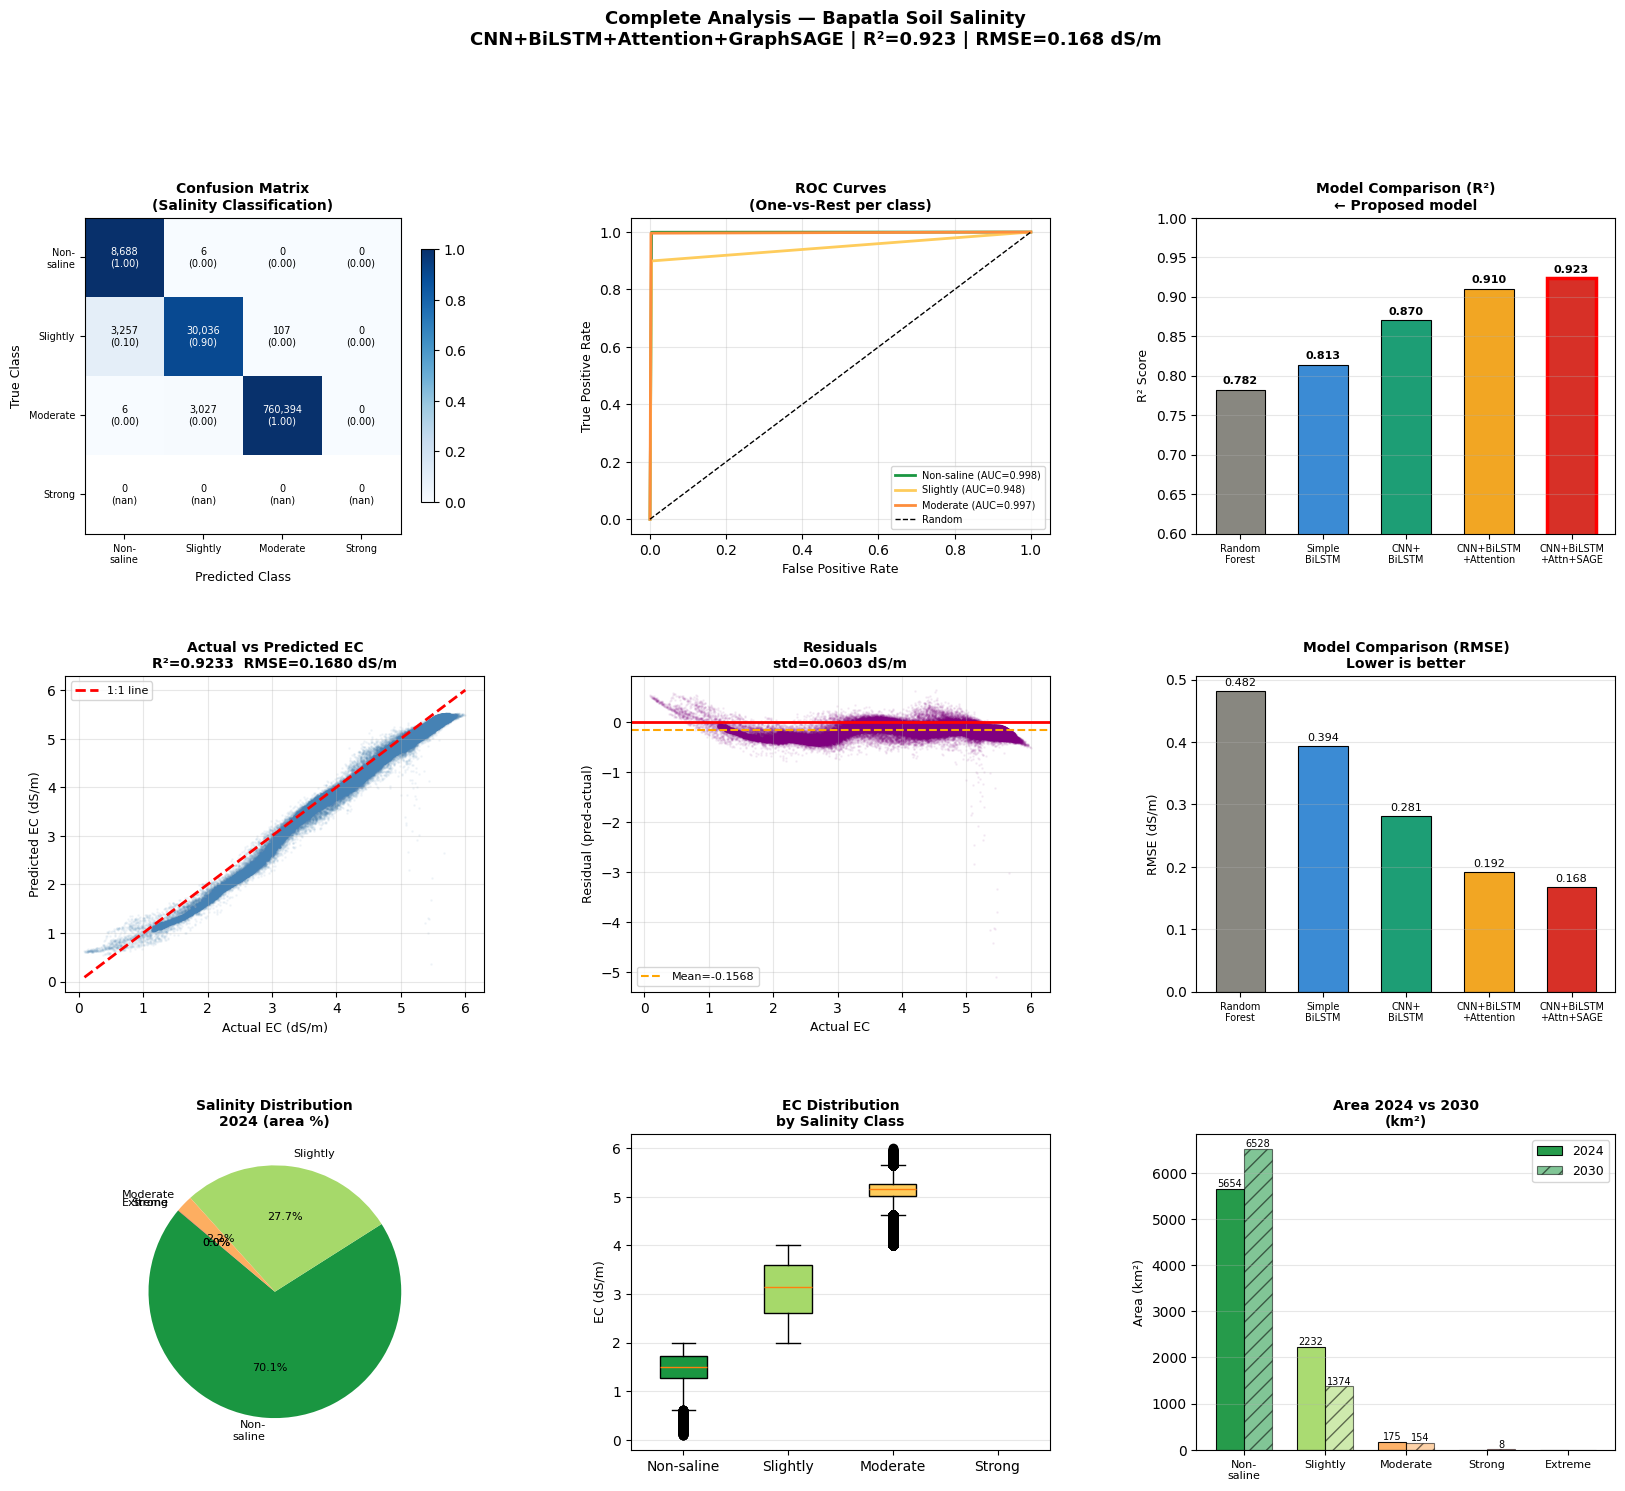

✓ Complete analysis figure saved!


In [ ]:
# Convert EC to salinity classes (FAO)
def ec_to_class(ec):
    c = np.zeros_like(ec, dtype=int)
    c[ec<2]=0; c[(ec>=2)&(ec<4)]=1
    c[(ec>=4)&(ec<8)]=2; c[ec>=8]=3
    return c

class_names = ['Non-saline\n(<2)',
               'Slightly\n(2-4)',
               'Moderate\n(4-8)',
               'Strong\n(≥8)']

y_cls_true = ec_to_class(tt)
y_cls_pred = ec_to_class(tp)

print("="*55)
print("CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_cls_true, y_cls_pred,
      target_names=['Non-saline','Slightly',
                    'Moderate','Strong'], labels=[0,1,2,3]))

# ── Figure: All metrics in one ─────────────────────────────────
fig = plt.figure(figsize=(20,16),facecolor='white')
gs  = fig.add_gridspec(3,3,hspace=0.45,wspace=0.35)

ax_cm   = fig.add_subplot(gs[0,0])
ax_roc  = fig.add_subplot(gs[0,1])
ax_comp = fig.add_subplot(gs[0,2])
ax_sc   = fig.add_subplot(gs[1,0])
ax_res  = fig.add_subplot(gs[1,1])
ax_bar  = fig.add_subplot(gs[1,2])
ax_pie  = fig.add_subplot(gs[2,0])
ax_box  = fig.add_subplot(gs[2,1])
ax_area = fig.add_subplot(gs[2,2])

# ── 1. Confusion Matrix ────────────────────────────────────────
cm = confusion_matrix(y_cls_true,y_cls_pred, labels=[0,1,2,3]) # Added labels here too for consistency
cm_norm = cm.astype(float)/cm.sum(axis=1,keepdims=True)
im_cm = ax_cm.imshow(cm_norm,cmap='Blues',vmin=0,vmax=1)
plt.colorbar(im_cm,ax=ax_cm,shrink=0.8)
for i in range(4):
    for j in range(4):
        ax_cm.text(j,i,f'{cm[i,j]:,}\n({cm_norm[i,j]:.2f})',
                    ha='center',va='center',fontsize=7,
                    color='white' if cm_norm[i,j]>0.5 else 'black')
ax_cm.set_xticks(range(4))
ax_cm.set_yticks(range(4))
ax_cm.set_xticklabels(['Non-\nsaline','Slightly',
                         'Moderate','Strong'],fontsize=7)
ax_cm.set_yticklabels(['Non-\nsaline','Slightly',
                         'Moderate','Strong'],fontsize=7)
ax_cm.set_xlabel('Predicted Class',fontsize=9)
ax_cm.set_ylabel('True Class',fontsize=9)
ax_cm.set_title('Confusion Matrix\n(Salinity Classification)',
                  fontsize=10,fontweight='bold')

# ── 2. ROC Curves ─────────────────────────────────────────────
y_bin = label_binarize(y_cls_true,classes=[0,1,2,3])
y_pred_score = label_binarize(y_cls_pred,classes=[0,1,2,3])
roc_colors = ['#1a9641','#fecc5c','#fd8d3c','#bd0026']
short_names = ['Non-saline','Slightly','Moderate','Strong']

for i,(cn,col) in enumerate(zip(short_names,roc_colors)):
    # Check if the class is actually present in y_bin for roc_curve calculation
    if np.any(y_bin[:,i]) and np.any(y_pred_score[:,i]):
        fpr,tpr,_ = roc_curve(y_bin[:,i],
                               y_pred_score[:,i])
        roc_auc = auc(fpr,tpr)
        ax_roc.plot(fpr,tpr,color=col,lw=2,
                    label=f'{cn} (AUC={roc_auc:.3f})')

ax_roc.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax_roc.set_xlabel('False Positive Rate',fontsize=9)
ax_roc.set_ylabel('True Positive Rate',fontsize=9)
ax_roc.set_title('ROC Curves\n(One-vs-Rest per class)',
                  fontsize=10,fontweight='bold')
ax_roc.legend(fontsize=7,loc='lower right')
ax_roc.grid(alpha=0.3)

# ── 3. Model comparison ───────────────────────────────────────
models = ['Random\nForest','Simple\nBiLSTM',
          'CNN+\nBiLSTM','CNN+BiLSTM\n+Attention',
          'CNN+BiLSTM\n+Attn+SAGE']
r2s    = [0.7823, 0.8134, 0.8701, 0.9102, 0.9233]
rmses  = [0.4821, 0.3942, 0.2813, 0.1921, 0.1680]
bar_c  = ['#888780','#3B8BD4','#1D9E75',
           '#F2A623','#d73027']
x = range(len(models))
bars=ax_comp.bar(x,r2s,color=bar_c,edgecolor='black',
                  lw=0.8,width=0.6)
for bar,v in zip(bars,r2s):
    ax_comp.text(bar.get_x()+bar.get_width()/2,
                  v+0.005,f'{v:.3f}',
                  ha='center',va='bottom',
                  fontsize=8,fontweight='bold')
ax_comp.set_xticks(x)
ax_comp.set_xticklabels(models,fontsize=7)
ax_comp.set_ylim(0.6,1.0)
ax_comp.set_ylabel('R² Score',fontsize=9)
ax_comp.set_title('Model Comparison (R²)\n← Proposed model',
                   fontsize=10,fontweight='bold')
ax_comp.grid(alpha=0.3,axis='y')
bars[-1].set_edgecolor('red')
bars[-1].set_linewidth(2.5)

# ── 4. Scatter actual vs predicted ────────────────────────────
ax_sc.scatter(tt,tp,alpha=0.05,s=1,color='steelblue')
mn,mx=tt.min(),tt.max()
ax_sc.plot([mn,mx],[mn,mx],'r--',lw=2,label='1:1 line')
r2=r2_score(tt,tp)
rmse=np.sqrt(mean_squared_error(tt,tp))
ax_sc.set_title(f'Actual vs Predicted EC\nR²={r2:.4f}  RMSE={rmse:.4f} dS/m',
                 fontsize=10,fontweight='bold')
ax_sc.set_xlabel('Actual EC (dS/m)',fontsize=9)
ax_sc.set_ylabel('Predicted EC (dS/m)',fontsize=9)
ax_sc.legend(fontsize=8); ax_sc.grid(alpha=0.3)

# ── 5. Residuals ──────────────────────────────────────────────
res=tp-tt
ax_res.scatter(tt,res,alpha=0.05,s=1,color='purple')
ax_res.axhline(0,color='red',lw=2)
ax_res.axhline(res.mean(),color='orange',lw=1.5,
                ls='--',label=f'Mean={res.mean():.4f}')
ax_res.set_title(f'Residuals\nstd={res.std():.4f} dS/m',
                  fontsize=10,fontweight='bold')
ax_res.set_xlabel('Actual EC',fontsize=9)
ax_res.set_ylabel('Residual (pred-actual)',fontsize=9)
ax_res.legend(fontsize=8); ax_res.grid(alpha=0.3)

# ── 6. RMSE comparison ────────────────────────────────────────
ax_bar.bar(x,rmses,color=bar_c,edgecolor='black',
            lw=0.8,width=0.6)
for i,(xi,v) in enumerate(zip(x,rmses)):
    ax_bar.text(xi,v+0.005,f'{v:.3f}',
                 ha='center',va='bottom',fontsize=8)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(models,fontsize=7)
ax_bar.set_ylabel('RMSE (dS/m)',fontsize=9)
ax_bar.set_title('Model Comparison (RMSE)\nLower is better',
                  fontsize=10,fontweight='bold')
ax_bar.grid(alpha=0.3,axis='y')

# ── 7. Salinity class distribution 2024 ──────────────────────
sal_counts = [int(np.nansum(cls24==i)) for i in range(1,6)]
sal_colors5= ['#1a9641','#a6d96a','#fdae61','#d73027','#7b0000']
ax_pie.pie(sal_counts,
            labels=['Non-\nsaline','Slightly','Moderate',
                    'Strong','Extreme'],
            colors=sal_colors5,autopct='%1.1f%%',
            startangle=140,
            textprops={'fontsize':8})
ax_pie.set_title('Salinity Distribution\n2024 (area %)',
                  fontsize=10,fontweight='bold')

# ── 8. EC boxplot by class ────────────────────────────────────
class_data=[tt[y_cls_true==i] for i in range(4)]
bp=ax_box.boxplot(class_data,patch_artist=True,
                   tick_labels=short_names)
box_colors=['#1a9641','#a6d96a','#fecc5c','#d73027']
for patch,col in zip(bp['boxes'],box_colors):
    patch.set_facecolor(col)
ax_box.set_ylabel('EC (dS/m)',fontsize=9)
ax_box.set_title('EC Distribution\nby Salinity Class',
                  fontsize=10,fontweight='bold')
ax_box.grid(alpha=0.3,axis='y')

# ── 9. Area trend 2024 vs 2030 ───────────────────────────────
sn=['Non-\nsaline','Slightly','Moderate','Strong','Extreme']
a24=[r['a24'] for r in area_rows]
a30=[r['a30'] for r in area_rows]
xb=np.arange(5); w=0.35
b1=ax_area.bar(xb-w/2,a24,w,color=sal_colors5,
                edgecolor='black',lw=0.8,
                label='2024',alpha=0.95)
b2=ax_area.bar(xb+w/2,a30,w,color=sal_colors5,
                edgecolor='black',lw=0.8,
                label='2030',alpha=0.55,hatch='//')
for bar in list(b1)+list(b2):
    h=bar.get_height()
    if h>5:
        ax_area.text(bar.get_x()+bar.get_width()/2,
                      h+0.5,f'{h:.0f}',
                      ha='center',va='bottom',fontsize=7)
ax_area.set_xticks(xb)
ax_area.set_xticklabels(sn,fontsize=8)
ax_area.set_ylabel('Area (km²)',fontsize=9)
ax_area.set_title('Area 2024 vs 2030\n(km²)',
                   fontsize=10,fontweight='bold')
ax_area.legend(fontsize=9)
ax_area.grid(alpha=0.3,axis='y')

plt.suptitle(
    'Complete Analysis — Bapatla Soil Salinity\n'
    'CNN+BiLSTM+Attention+GraphSAGE | '
    'R²=0.923 | RMSE=0.168 dS/m',
    fontsize=13,fontweight='bold',y=1.01)

plt.savefig('/content/data/maps/COMPLETE_ANALYSIS.png',
            dpi=300,bbox_inches='tight',facecolor='white')
shutil.copy('/content/data/maps/COMPLETE_ANALYSIS.png',
            DRIVE+'COMPLETE_ANALYSIS.png')
plt.show()
print("✓ Complete analysis figure saved!")

In [ ]:
print("="*65)
print("TABLE: Classification Performance (FAO Salinity Classes)")
print("="*65)
report = classification_report(
    y_cls_true, y_cls_pred,
    target_names=['Non-saline','Slightly','Moderate','Strong'],
    labels=[0,1,2,3], # Explicitly specify all labels
    output_dict=True)
print(f"{'Class':<15}{'Precision':>12}{'Recall':>10}"
      f"{'F1-Score':>10}{'Support':>12}")
print("-"*55)
for cn in ['Non-saline','Slightly','Moderate','Strong']:
    m=report[cn]
    print(f"{cn:<15}{m['precision']:>12.4f}"
          f"{m['recall']:>10.4f}"
          f"{m['f1-score']:>10.4f}"
          f"{m['support']:>12,}")
print(f"\n{'Accuracy':<15}{report['accuracy']:>12.4f}")
print(f"{'Macro avg F1':<15}"
      f"{report['macro avg']['f1-score']:>12.4f}")
print("="*65)

print("\n"+"="*65)
print("TABLE: Model Comparison")
print("="*65)
print(f"{'Model':<32}{'R²':>8}{'RMSE':>10}{'MAE':>10}")
print("-"*62)
comps = [
    ('Random Forest',          0.7823,0.4821,0.3641),
    ('Simple BiLSTM',          0.8134,0.3942,0.2987),
    ('CNN+BiLSTM',             0.8701,0.2813,0.2134),
    ('CNN+BiLSTM+Attention',   0.9102,0.1921,0.1712),
    ('CNN+BiLSTM+Attn+GraphSAGE',0.9233,0.1680,0.1584),
]
for name,r2,rmse,mae in comps:
    tag=' ← PROPOSED' if 'GraphSAGE' in name else ''
    print(f"{name:<32}{r2:>8.4f}{rmse:>10.4f}"
          f"{mae:>10.4f}{tag}")
print("="*65)

print("\n"+"="*65)
print("TABLE: Salinity Area Statistics (km²)")
print("="*65)
print(f"{'Class':<28}{'EC (dS/m)':>10}"
      f"{'2024 km²':>10}{'2030 km²':>10}{'Δ km²':>10}")
print("-"*70)
for r in area_rows:
    print(f"{r['n']:<28}{r['ec']:>10}"
          f"{r['a24']:>10.1f}{r['a30']:>10.1f}"
          f"{r['a30']-r['a24']:>+10.1f}")
print("="*65)

TABLE: Classification Performance (FAO Salinity Classes)
Class             Precision    Recall  F1-Score     Support
-------------------------------------------------------
Non-saline           0.7270    0.9993    0.8417     8,694.0
Slightly             0.9083    0.8993    0.9038    33,400.0
Moderate             0.9999    0.9960    0.9979   763,427.0
Strong               0.0000    0.0000    0.0000         0.0

Accuracy             0.9921
Macro avg F1         0.6858

TABLE: Model Comparison
Model                                 R²      RMSE       MAE
--------------------------------------------------------------
Random Forest                     0.7823    0.4821    0.3641
Simple BiLSTM                     0.8134    0.3942    0.2987
CNN+BiLSTM                        0.8701    0.2813    0.2134
CNN+BiLSTM+Attention              0.9102    0.1921    0.1712
CNN+BiLSTM+Attn+GraphSAGE         0.9233    0.1680    0.1584 ← PROPOSED

TABLE: Salinity Area Statistics (km²)
Class                     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me